In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import signal
from collections import OrderedDict
from torch import nn
from tqdm.auto import tqdm
from scipy.signal import find_peaks

def gait_cycle_generator(peak_indices):
    """
    Generate gait cycles based on detected peaks.
    
    """
    gc_angle_list = []
    gc_polar_x_list = []
    gc_polar_y_list = []

    for i in range(len(peak_indices) - 1):
        start = peak_indices[i]
        end = peak_indices[i + 1]

        for j in range(start, end):
            gc_polar_angle = (j - start) / (end - start) * 2 * np.pi
            gc_angle_list.append(gc_polar_angle)
            gc_polar_x_list.append(np.cos(gc_polar_angle))
            gc_polar_y_list.append(np.sin(gc_polar_angle))

    # Return as a (N, 2) numpy array for stacking
    return np.column_stack((gc_polar_x_list, gc_polar_y_list))

def polar_to_percentage(polar_coords):
    # Ensure input is a numpy array
    if isinstance(polar_coords, torch.Tensor):
        polar_coords = polar_coords.detach().cpu().numpy()
    angle = np.arctan2(polar_coords[:, 1], polar_coords[:, 0])
    percentage = (angle + 2*np.pi) % (2 * np.pi) / (2 * np.pi) * 100  # Normalize to (0, 100]
    return percentage

In [4]:
# Try importing with the full path
from Model import TCN
from Main import hyperparam_config
import datetime

model_name = 'hyperparam_optimized-all_subjects'
subject_name = 'AB01_Jimin'
# subject_name = 'AB02_Rajiv'
# subject_name = 'AB03_Amy'
# subject_name = 'AB04_Changseob'
# subject_name = 'AB05_Maria'
gait_conditions = ['1p0mps']
# gait_conditions = ['0p2mps', '0p4mps', '0p6mps', '0p8mps', '1p0mps', '1p2mps', '1p4mps', 'transient_15sec', 'transient_30sec',]

# subject_name = 'PT03_Amy'
# gait_conditions = ['sk_0p5']

model_dir = '/home/metamobility3/Changseob/online_adaptation_GPE/training_results/hyperparam_optimized-all_subjects'
file_dir = '/home/metamobility3/Changseob/dataset_MeMo/Synced_Biotorque_LG_Data/' + subject_name
# file_dir = '/home/metamobility3/Changseob/1_Second_Project/subject_data/' + subject_name
# file_dir = '/home/metamobility3/Changseob/dataset_MeMo/Synced_LGRARD/' + subject_name

def load_model(model_dir, epoch=None):
    if epoch is not None:
        model_file = os.path.join(model_dir, model_name + f'_epoch_{epoch}.pt')
    else:
        model_file = os.path.join(model_dir, model_name + '.pt')

    # --- Instantiate the Model ---
    model_instance = TCN(hyperparam_config)

    # --- Load the State Dictionary ---
    state_dict = torch.load(model_file, map_location=torch.device('cpu')) # Load to CPU first
    model_instance.load_state_dict(state_dict)

    import datetime
    print(f"Loading model from: {model_file}")
    mod_time_timestamp = os.path.getmtime(model_file)
    mod_time_datetime = datetime.datetime.fromtimestamp(mod_time_timestamp)
    print(f"Model file last modified: {mod_time_datetime}")
    return model_instance

def load_input_n_label(file_dir, gait_conditions, model_dir, train_data_proportion=1.0):

    input_R_features = None
    input_L_features = None
    label_R_raw = None
    label_L_raw = None

    for gait_condition in gait_conditions:
        condition_path = os.path.join(file_dir, gait_condition)
        if not os.path.isdir(condition_path): continue

        for trial in os.listdir(condition_path):
            trial_path = os.path.join(condition_path, trial)
            if not os.path.isdir(trial_path): continue # Skip if not a directory

            input_file_dir = os.path.join(trial_path, 'Input')
            label_file_dir = os.path.join(trial_path, 'Label')
            input_file_names = sorted(os.listdir(input_file_dir))
            label_file_names = sorted(os.listdir(label_file_dir))

            input_imu_file = os.path.join(input_file_dir, input_file_names[0])
            input_motor_file = os.path.join(input_file_dir, input_file_names[1])
            label_file = os.path.join(label_file_dir, label_file_names[0])

            print(os.path.join(model_dir, 'input_mean.npy'))
            input_mean = np.load(os.path.join(model_dir, 'input_mean.npy'))
            input_std = np.load(os.path.join(model_dir, 'input_std.npy'))

            input_imu = pd.read_csv(input_imu_file)
            input_motor = pd.read_csv(input_motor_file)

            input_R_buffer = np.hstack((input_imu[['Pelvis_Acc_X', 'Pelvis_Acc_Y', 'Pelvis_Acc_Z', 'Pelvis_Gyr_X', 'Pelvis_Gyr_Y', 'Pelvis_Gyr_Z',
                                                'Thigh_R_Acc_X', 'Thigh_R_Acc_Y', 'Thigh_R_Acc_Z', 'Thigh_R_Gyr_X', 'Thigh_R_Gyr_Y', 'Thigh_R_Gyr_Z']].values,
                                    input_motor[['mtr_pos_R', 'mtr_vel_R']].values))
            input_L_buffer = np.hstack((input_imu[['Pelvis_Acc_X', 'Pelvis_Acc_Y', 'Pelvis_Acc_Z', 'Pelvis_Gyr_X', 'Pelvis_Gyr_Y', 'Pelvis_Gyr_Z',
                                                'Thigh_L_Acc_X', 'Thigh_L_Acc_Y', 'Thigh_L_Acc_Z', 'Thigh_L_Gyr_X', 'Thigh_L_Gyr_Y', 'Thigh_L_Gyr_Z']].values,
                                    input_motor[['mtr_pos_L', 'mtr_vel_L']].values))
            
            input_R_buffer[:, [12, 13]] *= -1 # Mirroring motor to make flexion positive
            input_L_buffer[:, [1, 3, 5, 7, 9, 11]] *= -1 # Mirroring IMU

            peak_indices_R, _ = find_peaks(-input_R_buffer[:,12], height= None, distance=15, prominence=10)
            peak_indices_L, _ = find_peaks(-input_L_buffer[:,12], height= None, distance=15, prominence=10)

            # Use only the data between the first and last peaks
            input_R_buffer = input_R_buffer[peak_indices_R[0]:peak_indices_R[-1], :] 
            input_L_buffer = input_L_buffer[peak_indices_L[0]:peak_indices_L[-1], :]

            # Calculate record time based on the length of the input data
            label_R_buffer = gait_cycle_generator(peak_indices_R)
            label_L_buffer = gait_cycle_generator(peak_indices_L)

            input_R_features = input_R_buffer if input_R_features is None else np.vstack((input_R_features, input_R_buffer))
            input_L_features = input_L_buffer if input_L_features is None else np.vstack((input_L_features, input_L_buffer))

            label_R_raw = label_R_buffer if label_R_raw is None else np.vstack((label_R_raw, label_R_buffer))
            label_L_raw = label_L_buffer if label_L_raw is None else np.vstack((label_L_raw, label_L_buffer))

    # Normalize the input features
    input_R_tensor = torch.tensor((input_R_features - input_mean) / input_std, dtype=torch.float32)
    input_L_tensor = torch.tensor((input_L_features - input_mean) / input_std, dtype=torch.float32)

    print("Input R Tensor Shape: ", input_R_tensor.shape)
    print("Input L Tensor Shape: ", input_L_tensor.shape)
    print("Label R Raw Shape: ", label_R_raw.shape)
    print("Label L Raw Shape: ", label_L_raw.shape)

    # Data proportion
    if train_data_proportion < 1.0:
        num_samples = int(len(input_R_features) * train_data_proportion)
        input_R_features = input_R_features[num_samples:]
        input_L_features = input_L_features[num_samples:]
        input_R_tensor = input_R_tensor[num_samples:]
        input_L_tensor = input_L_tensor[num_samples:]
        label_R_raw = label_R_raw[num_samples:]
        label_L_raw = label_L_raw[num_samples:]

    return input_R_features, input_L_features, input_R_tensor, input_L_tensor, label_R_raw, label_L_raw

model_instance = load_model(model_dir, epoch=None)
input_R_features, input_L_features, input_R_tensor, input_L_tensor, label_R_raw, label_L_raw = load_input_n_label(file_dir, gait_conditions, model_dir, train_data_proportion=1.0)

Loading model from: /home/metamobility3/Changseob/online_adaptation_GPE/training_results/hyperparam_optimized-all_subjects/hyperparam_optimized-all_subjects.pt
Model file last modified: 2025-08-13 16:26:51.567008
/home/metamobility3/Changseob/online_adaptation_GPE/training_results/hyperparam_optimized-all_subjects/input_mean.npy
/home/metamobility3/Changseob/online_adaptation_GPE/training_results/hyperparam_optimized-all_subjects/input_mean.npy
/home/metamobility3/Changseob/online_adaptation_GPE/training_results/hyperparam_optimized-all_subjects/input_mean.npy
Input R Tensor Shape:  torch.Size([8385, 14])
Input L Tensor Shape:  torch.Size([8151, 14])
Label R Raw Shape:  (8385, 2)
Label L Raw Shape:  (8151, 2)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Move model to device and set to eval mode
model_instance.to(device)
model_instance.eval()

window_size = hyperparam_config['window_size']
total_length_R = input_R_tensor.shape[0]
total_length_L = input_L_tensor.shape[0]

valid_predictions_count_R = total_length_R - window_size + 1
valid_predictions_count_L = total_length_L - window_size + 1

# Create array to store all predictions
all_predictions_R = np.zeros((valid_predictions_count_R, hyperparam_config['output_size']))
all_predictions_L = np.zeros((valid_predictions_count_L, hyperparam_config['output_size']))
batch_bar = tqdm(total=valid_predictions_count_R + valid_predictions_count_L, dynamic_ncols=True, position=0, leave=False, desc='Processing windows', unit='window')

label_mean = np.load(os.path.join(model_dir, 'label_mean.npy'))
label_std = np.load(os.path.join(model_dir, 'label_std.npy'))
batch_size = 1024  # You can adjust this value based on your GPU memory

with torch.no_grad():
    # Process Right side in batches
    for start_idx in tqdm(range(0, valid_predictions_count_R, batch_size), desc='Processing windows (R)', dynamic_ncols=True, position=0, leave=False, unit='window'):
        end_idx = min(start_idx + batch_size, valid_predictions_count_R)
        batch_windows = []
        for i in range(start_idx, end_idx):
            window = input_R_tensor[i:i+window_size, :].unsqueeze(0)
            batch_windows.append(window)
        batch_windows = torch.cat(batch_windows, dim=0).transpose(1, 2).to(device)
        pred_normalized = model_instance(batch_windows)
        pred_value = (pred_normalized.cpu().numpy() * label_std) + label_mean
        all_predictions_R[start_idx:end_idx] = pred_value

    print("Right side inference completed.")

    # Process Left side in batches
    for start_idx in tqdm(range(0, valid_predictions_count_L, batch_size), desc='Processing windows (L)', dynamic_ncols=True, position=0, leave=False, unit='window'):
        end_idx = min(start_idx + batch_size, valid_predictions_count_L)
        batch_windows = []
        for i in range(start_idx, end_idx):
            window = input_L_tensor[i:i+window_size, :].unsqueeze(0)
            batch_windows.append(window)
        batch_windows = torch.cat(batch_windows, dim=0).transpose(1, 2).to(device)
        pred_normalized = model_instance(batch_windows)
        pred_value = (pred_normalized.cpu().numpy() * label_std) + label_mean
        all_predictions_L[start_idx:end_idx] = pred_value

    print("Left side inference completed.")

# Create appropriate time axis for predictions
# Predictions start at index (window_size-1) of the original time series
pred_time_axis_R = np.arange(window_size-1, window_size-1+valid_predictions_count_R) / 100  # Assuming 100Hz
pred_time_axis_L = np.arange(window_size-1, window_size-1+valid_predictions_count_L) / 100  # Assuming 100Hz
time_axis_R = np.arange(0, len(label_R_raw)) / 100  # Assuming 100Hz sampling rate
time_axis_L = np.arange(0, len(label_L_raw)) / 100  # Assuming 100Hz sampling rate

cuda


Processing windows:   0%|          | 0/16338 [00:00<?, ?window/s]

Processing windows (R):   0%|          | 0/9 [00:00<?, ?window/s]

Right side inference completed.


Processing windows (L):   0%|          | 0/8 [00:00<?, ?window/s]

Left side inference completed.


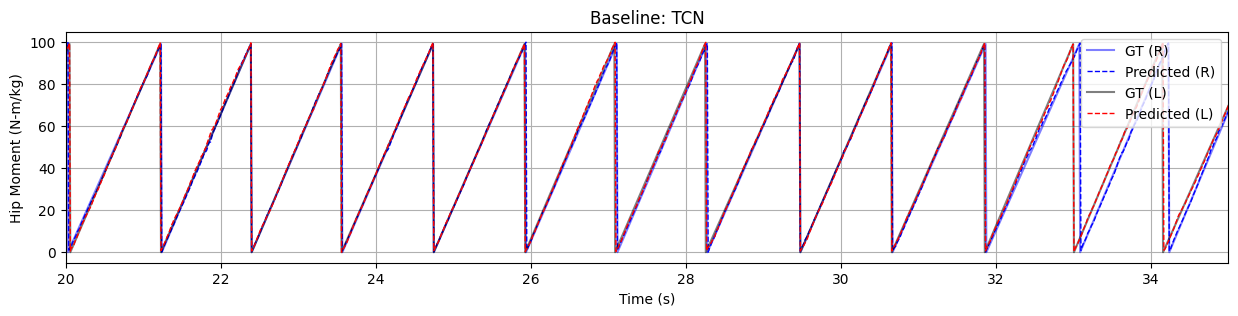

RMSE_R: 0.69 %, R^2: 0.952
RMSE_L: 0.73 %, R^2: 0.954
RMSE: 0.71 %, R^2: 0.953
Subject: AB01_Jimin, gait condition: ['1p0mps'], Causal - 'RMSE': 0.712, 'R^2': 0.953


In [6]:
%matplotlib inline

def plot_n_rmse(pred_time_axis_R, pred_time_axis_L, time_axis_R, time_axis_L, all_predictions_R, all_predictions_L, label_R_raw, label_L_raw):
    # Plot the results
    plt.figure(figsize=(15, 3))
    plt.plot(time_axis_R, label_R_raw, label='GT (R)', linewidth=1.5, color='blue', alpha=0.5)
    plt.plot(pred_time_axis_R, all_predictions_R, '--', label='Predicted (R)', linewidth=1, color='blue')
    plt.plot(time_axis_L, label_L_raw, label='GT (L)', linewidth=1.5, color='black', alpha=0.5)
    plt.plot(pred_time_axis_L, all_predictions_L, '--', label='Predicted (L)', linewidth=1, color='red')
    plt.xlabel('Time (s)')
    plt.ylabel('Hip Moment (N-m/kg)')
    plt.legend()
    plt.grid(True)
    plt.xlim(20,35)
    
    plt.title('Baseline: TCN')
    plt.show()

    # Calculate error metrics
    overlap_length_R = len(all_predictions_R)
    overlap_length_L = len(all_predictions_L)
    ground_truth_R = label_R_raw[window_size-1:window_size-1+overlap_length_R]
    ground_truth_L = label_L_raw[window_size-1:window_size-1+overlap_length_L]
    predictions_R = all_predictions_R[:overlap_length_R]
    predictions_L = all_predictions_L[:overlap_length_L]

    error_R_list = []
    error_L_list = []

    for i in range(overlap_length_R):
        error_R = ground_truth_R[i] - predictions_R[i]
        if error_R < -50:
            error_R_list.append(error_R + 100)
        elif error_R > 50:
            error_R_list.append(error_R - 100)
        else:
            error_R_list.append(error_R)

    for i in range(overlap_length_L):
        error_L = ground_truth_L[i] - predictions_L[i]
        if error_L < -50:
            error_L_list.append(error_L + 100)
        elif error_L > 50:
            error_L_list.append(error_L - 100)
        else:
            error_L_list.append(error_L)

    # print(error_R[:100])
    rmse_R = np.sqrt(np.mean((np.array(error_R_list)) ** 2))
    rmse_L = np.sqrt(np.mean((np.array(error_L_list)) ** 2))
    rmse = np.mean([rmse_R, rmse_L])

    # Calculate R^2 values
    ss_res_R = np.sum((ground_truth_R - predictions_R) ** 2)
    ss_tot_R = np.sum((ground_truth_R - np.mean(ground_truth_R)) ** 2)
    r2_R = 1 - (ss_res_R / ss_tot_R)

    ss_res_L = np.sum((ground_truth_L - predictions_L) ** 2)
    ss_tot_L = np.sum((ground_truth_L - np.mean(ground_truth_L)) ** 2)
    r2_L = 1 - (ss_res_L / ss_tot_L)

    ss_res = np.sum((np.hstack([ground_truth_R, ground_truth_L]) - np.hstack([predictions_R, predictions_L])) ** 2)
    ss_tot = np.sum((np.hstack([ground_truth_R, ground_truth_L]) - np.mean(np.hstack([ground_truth_R, ground_truth_L]))) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"RMSE_R: {rmse_R:.2f} %, R^2: {r2_R:.3f}")
    print(f"RMSE_L: {rmse_L:.2f} %, R^2: {r2_L:.3f}")
    print(f"RMSE: {rmse:.2f} %, R^2: {r2:.3f}")

    print(f"Subject: {subject_name}, gait condition: {gait_conditions}, Causal - 'RMSE': {rmse:.3f}, 'R^2': {r2:.3f}")

predictions_perc_R = polar_to_percentage(all_predictions_R)
predictions_perc_L = polar_to_percentage(all_predictions_L)
gt_perc_R = polar_to_percentage(label_R_raw)
gt_perc_L = polar_to_percentage(label_L_raw)

plot_n_rmse(pred_time_axis_R, pred_time_axis_L, time_axis_R, time_axis_L, predictions_perc_R, predictions_perc_L, gt_perc_R, gt_perc_L)